# NorthStar — R Analytics


In [ ]:
install.packages("dplyr")
install.packages("ggplot2")
library(dplyr)
library(ggplot2)
print("packages loaded")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "packages loaded"


In [ ]:
base_url <- "https://raw.githubusercontent.com/chelsajn/DBAnew/main/"

orders     <- read.csv(paste0(base_url, "orders.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
customers  <- read.csv(paste0(base_url, "customers.csv"))
drivers    <- read.csv(paste0(base_url, "drivers.csv"))
vehicles   <- read.csv(paste0(base_url, "vehicles.csv"))
hubs       <- read.csv(paste0(base_url, "hubs.csv"))
complaints <- read.csv(paste0(base_url, "complaints.csv"))
incidents  <- read.csv(paste0(base_url, "incidents.csv"))
app_events <- read.csv(paste0(base_url, "app_events.csv"))

## Data Cleaning

In [ ]:
#fixing zone names

orders$pickup_zone[orders$pickup_zone == "north"] <- "North"
orders$pickup_zone[orders$pickup_zone == "NORTH"] <- "North"

orders$dropoff_zone[orders$dropoff_zone == "south"] <- "South"
orders$dropoff_zone[orders$dropoff_zone == "SOUTH"] <- "South"

#replacing missing ratings with median
med_rating <- median(deliveries$customer_rating_post_delivery, na.rm = TRUE)

deliveries$customer_rating_post_delivery[
  is.na(deliveries$customer_rating_post_delivery)
] <- med_rating
cat("cleaning done\n")

cleaning done


## Merge Data

In [ ]:
df <- merge(orders, deliveries, by = "order_id")
df <- merge(df, drivers[, c("driver_id", "years_experience", "training_score", "driver_rating", "employment_type")], by = "driver_id")
df <- merge(df, hubs[, c("hub_id", "hub_name", "zone")], by = "hub_id")
df$is_failed <- ifelse(df$delivery_status == "Failed", 1, 0)
cat("merged dataframe:", nrow(df), "rows x", ncol(df), "columns\n")
head(df)

merged dataframe: 950 rows x 30 columns


,hub_id,driver_id,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,⋯,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,years_experience,training_score,driver_rating,employment_type,hub_name,zone,is_failed
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
1,H01,D020,O00596,C0394,Parcel,2025-10-02 01:54:00,12,SOUTH,East,Low,⋯,0,3.73,20.45,6,NA,4.61,FullTime,North Exchange,North,0
2,H01,D005,O00456,C0124,Parcel,2024-01-16 03:31:00,2,East,RiverSide,High,⋯,0,4.96,8.10,3,69.7,4.14,FullTime,North Exchange,North,0
3,H01,D097,O00585,C0160,Medical,2025-02-25 13:02:00,1,SOUTH,RiverSide,Medium,⋯,0,3.11,13.31,2,79.1,4.48,FullTime,North Exchange,North,1
4,H01,D049,O00147,C0096,Retail,2024-07-12 07:43:00,6,North,WEST,Critical,⋯,0,4.34,12.87,14,41.4,4.00,Contract,North Exchange,North,0
5,H01,D115,O00298,C0184,Parcel,2025-01-06 04:40:00,4,WEST,north,Low,⋯,0,4.80,13.26,11,69.5,4.77,FullTime,North Exchange,North,0
6,H01,D055,O00624,C0117,Passenger,2025-04-13 04:21:00,24,WEST,Ctr,Medium,⋯,0,4.28,11.80,15,90.5,5.00,FullTime,North Exchange,North,0


## Statistical Analysis

In [ ]:
cat("Summary stats for order_value:\n")
print(summary(df$order_value))
cat("\nSummary stats for route_distance_km:\n")
print(summary(df$route_distance_km))
cat("\nSummary stats for customer_rating_post_delivery:\n")
print(summary(df$customer_rating_post_delivery))

Summary stats for order_value:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   48.61   77.17   91.86  122.82  510.06 

Summary stats for route_distance_km:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 

Summary stats for customer_rating_post_delivery:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.373   4.040   3.867   4.550   5.000 


In [ ]:
cat("Standard deviation of fuel cost:", round(sd(df$fuel_or_charge_cost, na.rm=TRUE), 2), "\n")
cat("Standard deviation of order value:", round(sd(df$order_value, na.rm=TRUE), 2), "\n")
cat("Correlation - driver rating vs customer rating:",
    round(cor(df$driver_rating, df$customer_rating_post_delivery, use="complete.obs"), 3), "\n")
cat("Correlation - route distance vs fuel cost:",
    round(cor(df$route_distance_km, df$fuel_or_charge_cost, use="complete.obs"), 3), "\n")

Standard deviation of fuel cost: 4.34 
Standard deviation of order value: 62 
Correlation - driver rating vs customer rating: 0.097 
Correlation - route distance vs fuel cost: 0.524 


In [ ]:
#overall failure rate
fail_rate <- round(mean(df$is_failed) * 100, 1)
cat("Overall delivery failure rate:", fail_rate, "%\n")

#delivery status breakdown
cat("\nDelivery status counts:\n")
print(table(df$delivery_status))

Overall delivery failure rate: 13.9 %

Delivery status counts:

Delayed  Failed  OnTime 
    202     132     616 


In [ ]:
#zone level summary
zone_summary <- df %>%
  group_by(pickup_zone) %>%
  summarise(
    total = n(),
    failed = sum(is_failed),
    failure_rate = round(mean(is_failed) * 100, 1),
    avg_rating = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2)
  ) %>%
  arrange(desc(failure_rate))

# converting tibble to dataframe
zone_summary <- as.data.frame(zone_summary)

cat("Zone performance summary:\n")
print(zone_summary)

Zone performance summary:
   pickup_zone total failed failure_rate avg_rating
1    RiverSide    66     14         21.2       3.80
2      CENTRAL    55     11         20.0       3.65
3      Central    55     11         20.0       3.62
4          Ctr    64     11         17.2       3.43
5        North   135     22         16.3       3.90
6         EAST    78     11         14.1       3.87
7         West    51      7         13.7       3.94
8        South    83     10         12.0       4.00
9      Airport    67      8         11.9       3.87
10        WEST    63      7         11.1       3.86
11        East    78      8         10.3       3.96
12     AIRPORT    46      4          8.7       4.16
13   Riverside    53      4          7.5       3.95
14       SOUTH    56      4          7.1       4.14


In [ ]:
#hub performance
hub_summary <- df %>%
  group_by(hub_name) %>%
  summarise(
    total = n(),
    failed = sum(is_failed),
    failure_rate = round(mean(is_failed) * 100, 1),
    avg_rating = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2)
  ) %>%
  arrange(desc(failure_rate))

# converting tibble to normal dataframe
hub_summary <- as.data.frame(hub_summary)

cat("Hub performance summary:\n")
print(hub_summary)

Hub performance summary:
        hub_name total failed failure_rate avg_rating
1  Midtown Relay   128     26         20.3       3.89
2   Central Core   115     23         20.0       3.68
3    Airport Hub   104     15         14.4       3.88
4      West Gate   127     16         12.6       3.92
5 North Exchange   136     17         12.5       3.84
6  Riverside Hub   115     14         12.2       3.88
7     South Link   106     10          9.4       3.95
8      East Dock   119     11          9.2       3.90


## Visualisations using ggplot2

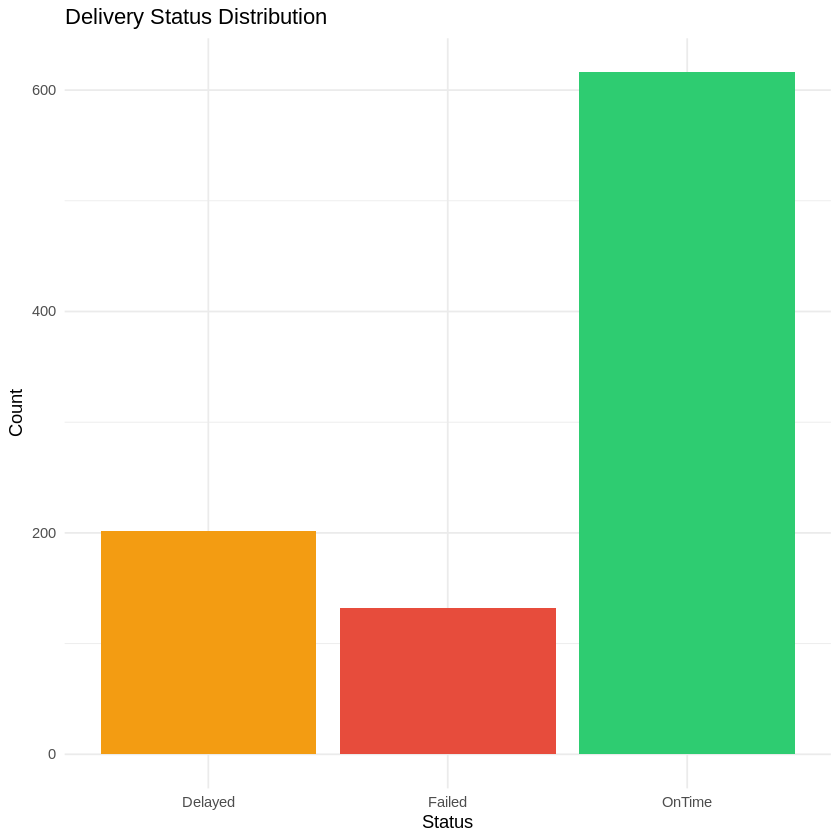

In [ ]:
#plot 1 - delivery status bar chart
ggplot(df, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  scale_fill_manual(values = c("OnTime" = "#2ecc71", "Delayed" = "#f39c12", "Failed" = "#e74c3c")) +
  labs(title = "Delivery Status Distribution", x = "Status", y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")

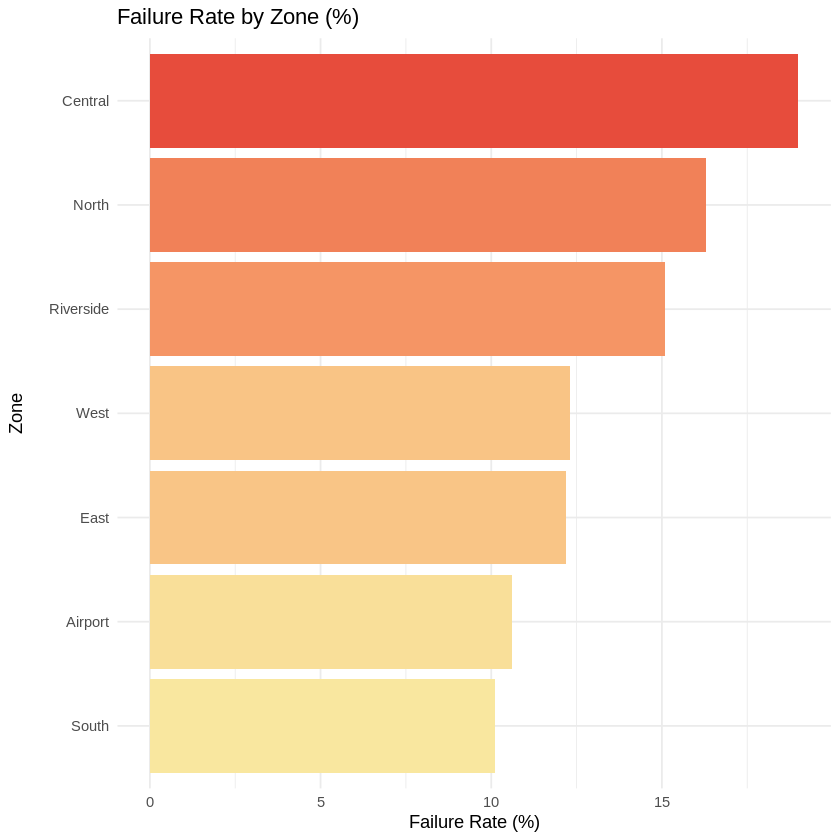

In [ ]:
#plot 2 - failure rate by zone
ggplot(zone_summary, aes(x = reorder(pickup_zone, failure_rate), y = failure_rate, fill = failure_rate)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "#f9e79f", high = "#e74c3c") +
  labs(title = "Failure Rate by Zone (%)", x = "Zone", y = "Failure Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'


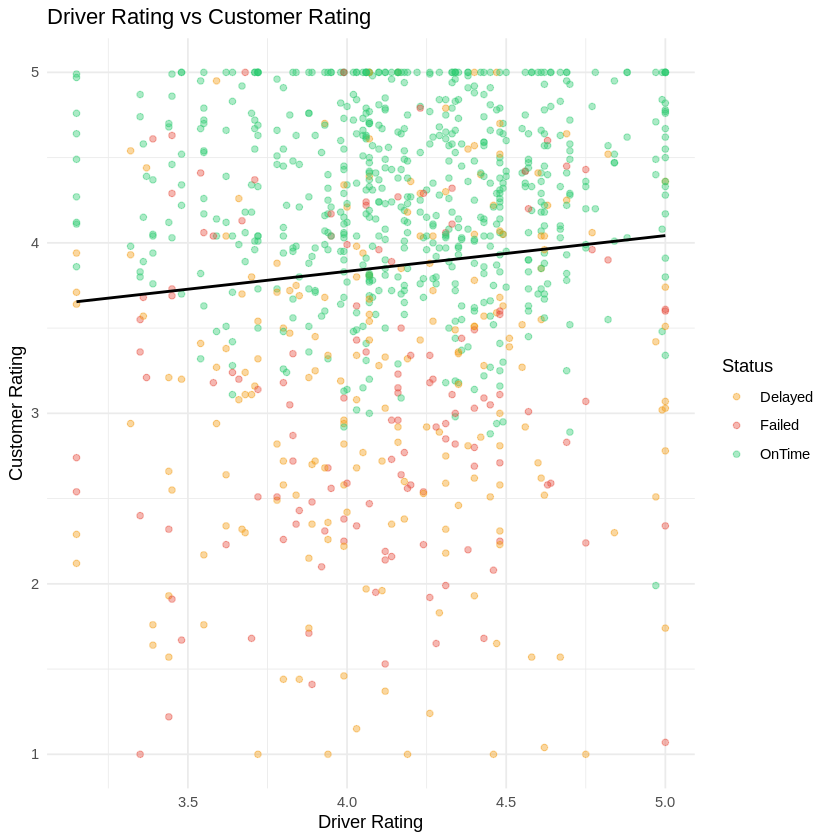

In [ ]:
#plot 3 - scatter driver rating vs customer rating
ggplot(df, aes(x = driver_rating, y = customer_rating_post_delivery, colour = delivery_status)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", se = FALSE, colour = "black", linewidth = 0.8) +
  scale_colour_manual(values = c("OnTime" = "#2ecc71", "Delayed" = "#f39c12", "Failed" = "#e74c3c")) +
  labs(title = "Driver Rating vs Customer Rating",
       x = "Driver Rating", y = "Customer Rating", colour = "Status") +
  theme_minimal()

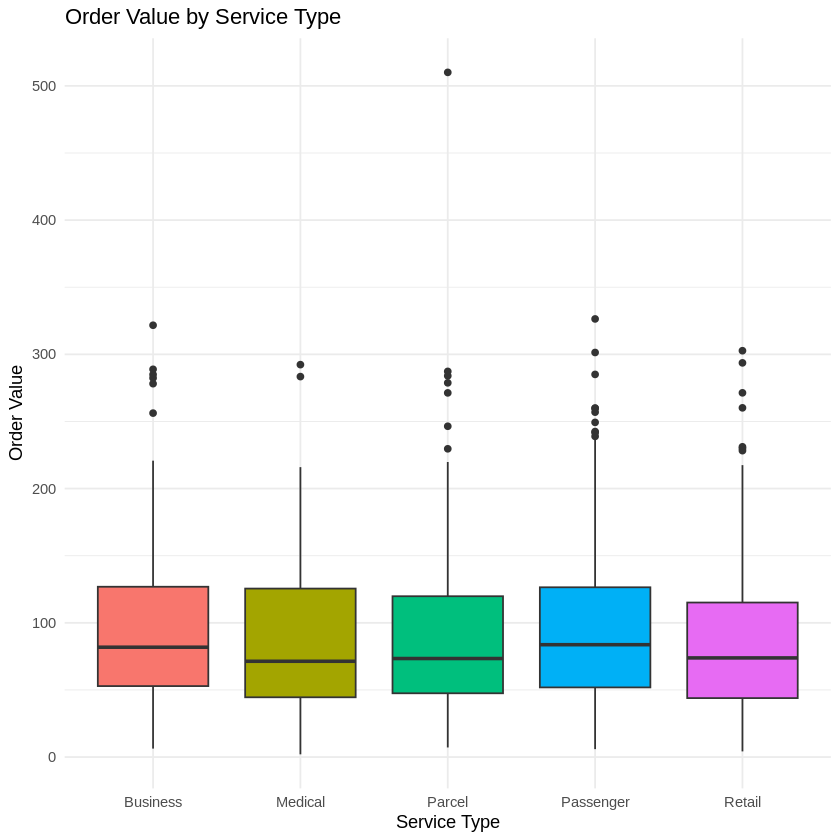

In [ ]:
#plot 4 - boxplot order value by service type
ggplot(df, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_boxplot() +
  labs(title = "Order Value by Service Type", x = "Service Type", y = "Order Value") +
  theme_minimal() +
  theme(legend.position = "none")

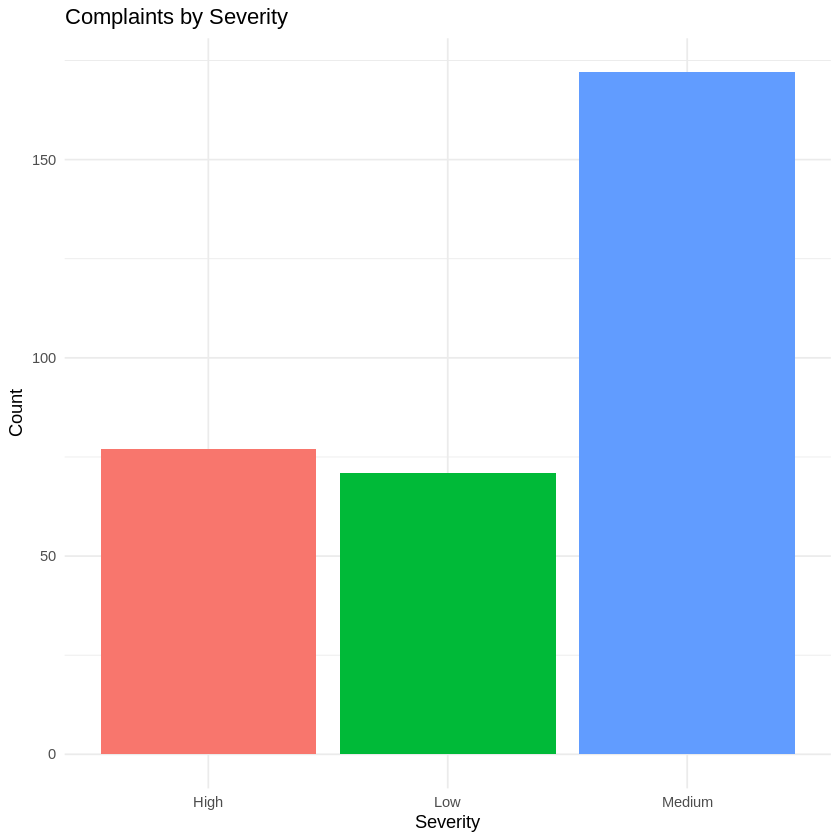

In [10]:
#plot 5 - complaints by severity
comp_summary <- complaints %>%
  group_by(severity) %>%
  summarise(total = n())

ggplot(comp_summary, aes(x = severity, y = total, fill = severity)) +
  geom_bar(stat = "identity") +
  labs(title = "Complaints by Severity", x = "Severity", y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")

## Summary

The R analytics confirmed several key patterns in the NorthStar data:
- A significant proportion of deliveries fail or are delayed
- Some zones consistently have higher failure rates than others
- Driver rating positively correlates with customer satisfaction
- Route distance and fuel cost are strongly linked
- High severity complaints are not evenly spread across service types